### Precision-Recall AUC (PR-AUC) Evaluation

This notebook presents the Precision-Recall Area Under the Curve (PR-AUC) as a key evaluation metric for assessing the performance of a machine learning model, particularly in the context of imbalanced classification tasks.


In [2]:
# Objective, Can you correctly classify the medical specialties based on the transcription text
#Let us import all the necessary libraries
import os
import numpy as np  
import pandas as pd 
import time
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline

import nltk
import re, string
from sklearn.model_selection import RandomizedSearchCV
from nltk import word_tokenize, sent_tokenize

from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.multiclass import OneVsRestClassifier
from sklearn.svm import SVC
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.preprocessing import LabelBinarizer,LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix
from mlxtend.plotting import plot_confusion_matrix
from sklearn.model_selection import GridSearchCV
from sklearn.model_selection import cross_validate
from sklearn.preprocessing import label_binarize
from sklearn.metrics import classification_report, confusion_matrix, roc_curve, auc


import warnings
warnings.filterwarnings("ignore") 

In [3]:
! pip install nltk
import nltk
from nltk.corpus import stopwords

# Download the stopwords dataset if not already downloaded
nltk.download('stopwords')

# Use the stopwords
stop_words = set(stopwords.words('english'))

#EDA
data = pd.read_csv('/kaggle/input/medicaltranscriptions/mtsamples.csv')
print(data.columns)
#data.head(5)

data.drop('Unnamed: 0',axis=1,inplace=True)

data.columns

# a function to preprocess the data
def Preprocessing(text):
    text = str(text)
    text = text.lower()
    text = re.sub(r'\([^)]*\)', '', text)
    text = re.sub('"','', text) 
    text = re.sub(r"'s\b","",text)
    text = re.sub("[^a-zA-Z]", " ", text) 
    tokens = [w for w in text.split() if not w in stop_words]
    long_words = [i for i in tokens if len(i)>=3]
    return (" ".join(long_words)).strip()

data['cleaned_transcription'] = data['transcription'].apply(Preprocessing)

print(data.columns)

# creating feature vectors and target vector
transcripts = data.cleaned_transcription.values
Y = data.medical_specialty.values

# label encode our categorical target variable
le = LabelEncoder()
Y = le.fit_transform(Y)

print(Y)

# function to create document-term matrix
def create_vec(strings):
  #tf = TfidfVectorizer(analyzer="char_wb", ngram_range=(1,3))
  tf = TfidfVectorizer(max_features = 6000, ngram_range=(1,3), min_df=5, max_df=0.9)
  tf.fit(strings)
  X = tf.fit_transform(strings)
  return X
vecs = create_vec(transcripts)# a function to preprocess the data

print(vecs)

# applying SMOTE oversampling method to upsample minority class labels
sm = SMOTE()
x_res, y_res = sm.fit_resample(vecs,Y)

df = pd.DataFrame({"class":list(y_res)})
df.head()

df['class'].value_counts()

# Splitting data into train:test by 80:20
x_train, x_val, y_train, y_val = train_test_split(x_res, y_res, test_size=0.2, random_state = 42)

x_train = x_train.toarray()
print('\nTraining features shape: ',x_train.shape)

x_val =x_val.toarray()
print('Test features shape:     ',x_val.shape)

# a function to train and evaluate model
def train_model(model, x_train,x_val,y_train,y_val):
  model.fit(x_train,y_train)
  prediction = model.predict(x_val)
  print('Accuracy',round(accuracy_score(prediction, y_val)*100, 0),'%')
  return model

[nltk_data] Downloading package stopwords to /usr/share/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.
Index(['Unnamed: 0', 'description', 'medical_specialty', 'sample_name',
       'transcription', 'keywords'],
      dtype='object')
Index(['description', 'medical_specialty', 'sample_name', 'transcription',
       'keywords', 'cleaned_transcription'],
      dtype='object')
[0 2 2 ... 0 0 0]
  (0, 3314)	0.09403042310250295
  (0, 908)	0.10238291501134683
  (0, 4064)	0.10735828324847223
  (0, 3528)	0.091052388350128
  (0, 5987)	0.07621250555094665
  (0, 5176)	0.1047122232206365
  (0, 5408)	0.10566288771279468
  (0, 149)	0.11042100614514046
  (0, 2991)	0.06482340517448347
  (0, 5920)	0.10599037032882767
  (0, 5229)	0.09315652072007759
  (0, 3313)	0.06423350875032413
  (0, 907)	0.09820037674998712
  (0, 5455)	0.1047122232206365
  (0, 3296)	0.10440537031218039
  (0, 573)	0.05168030582444491
  (0, 4063)	0.10735828324847223
  (0, 5861)	0.0747634135990948
  (0, 151)	0.0736017264805

Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best parameters from RandomizedSearchCV: {'tol': 1e-05, 'solver': 'liblinear', 'penalty': 'l2', 'multi_class': 'ovr', 'max_iter': 500, 'fit_intercept': False, 'class_weight': 'balanced', 'C': 1}
Best cross-validation score: 0.819072982774252
Cross-validation results:  {'fit_time': array([51.1461823 , 50.70895147]), 'score_time': array([0.27561903, 0.2688179 ]), 'test_score': array([0.81550317, 0.82264279])}
Classification report for Logistic Regression: 
                                 precision    recall  f1-score   support

          Allergy / Immunology     0.8662    1.0000    0.9283       233
                       Autopsy     1.0000    1.0000    1.0000       224
                    Bariatrics     0.9454    0.9657    0.9554       233
    Cardiovascular / Pulmonary     0.6066    0.5441    0.5736       204
                  Chiropractic     0.8062    0.9811    0.8851       212
    Consult - History and Phy.     0.3846    0

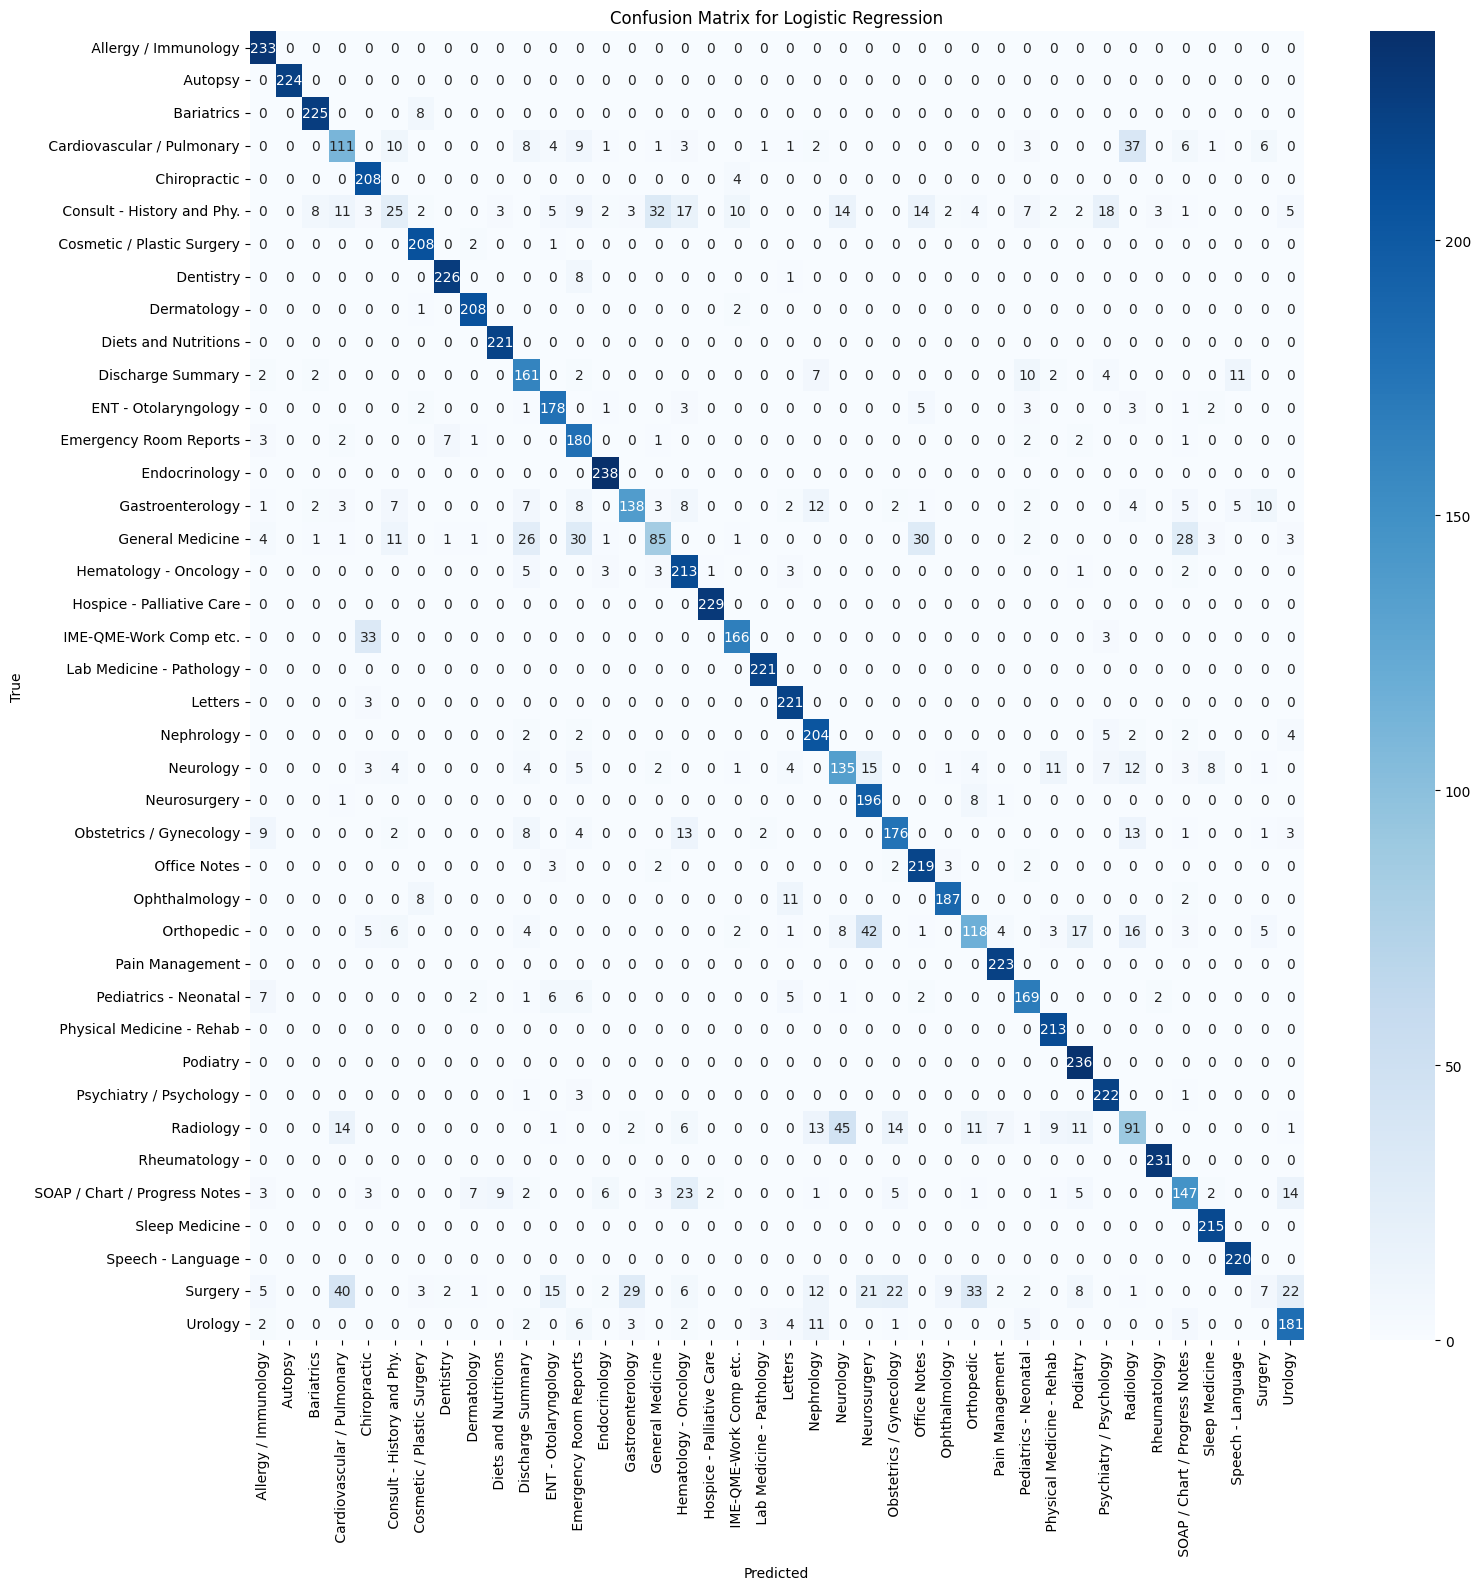

In [4]:
# ------------------------------------------
# Logistic Regression Classification Model
# ------------------------------------------

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.linear_model import LogisticRegression

# Logistic Regression classification model
classifier = LogisticRegression()

# Define the parameter distribution for hyperparameter tuning
param_dist = {
    'C': [0.1, 1, 10],
    'solver': ['liblinear', 'lbfgs', 'saga'],
    'max_iter': [100, 250, 500, 1000],
    'penalty': ['l2', 'l1', 'elasticnet'],
    'multi_class': ['auto', 'ovr', 'multinomial'],
    'fit_intercept': [True, False],
    'class_weight': [None, 'balanced'],
    'tol': [1e-5, 1e-3],
}

# Set up RandomizedSearchCV
random_search = RandomizedSearchCV(
    estimator=classifier,
    param_distributions=param_dist,
    n_iter=10,
    cv=2,
    n_jobs=-1,
    verbose=1,
    scoring='accuracy',
    random_state=42
)

# Fit the model
random_search.fit(x_train, y_train)

# Best parameters
print(f"Best parameters from RandomizedSearchCV: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_}")

# Best estimator
best_classifier = random_search.best_estimator_

# Cross-validation results
cv_results = cross_validate(best_classifier, x_train, y_train, cv=2)
print("Cross-validation results: ", cv_results)

# Predictions
prediction = best_classifier.predict(x_val)

# Classification report
print('Classification report for Logistic Regression: \n',
      classification_report(y_val, prediction, target_names=list(le.classes_), digits=4))

# Confusion Matrix
conf_matrix = confusion_matrix(y_val, prediction)
plt.figure(figsize=(17, 17))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for Logistic Regression')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# For binary classification (choose class 1 as positive)
# if len(np.unique(y_val)) == 2:
#     TP = conf_matrix[1, 1]
#     TN = conf_matrix[0, 0]
#     FP = conf_matrix[0, 1]
#     FN = conf_matrix[1, 0]

#     print(f"True Positives (TP): {TP}")
#     print(f"True Negatives (TN): {TN}")
#     print(f"False Positives (FP): {FP}")
#     print(f"False Negatives (FN): {FN}")

#     TPR = TP / (TP + FN)
#     FPR = FP / (FP + TN)

#     print(f"True Positive Rate (TPR): {TPR}")
#     print(f"False Positive Rate (FPR): {FPR}")

# --------------------------------------
# PR-AUC (Precision-Recall Curve and Area)
# --------------------------------------

# Get predicted probabilities
y_scores = best_classifier.predict_proba(x_val)

# Binarize labels
classes = np.unique(y_val)
y_val_bin = label_binarize(y_val, classes=classes)

# Handle binary vs. multiclass
# if y_scores.shape[1] == 2:
#     # Binary classification
#     precision, recall, _ = precision_recall_curve(y_val, y_scores[:, 1])
#     pr_auc = average_precision_score(y_val, y_scores[:, 1])

#     print(f"Precision-Recall AUC (PR-AUC): {pr_auc:.4f}")

#     plt.figure(figsize=(10, 10))
#     plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.4f})', color='purple')
#     plt.xlabel('Recall')
#     plt.ylabel('Precision')
#     plt.title('Precision-Recall Curve (Binary)')
#     plt.legend()
#     plt.grid()
#     plt.show()

# else:
#     # Multiclass classification
#     plt.figure(figsize=(10, 8))
#     for i in range(len(classes)):
#         precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_scores[:, i])
#         pr_auc = average_precision_score(y_val_bin[:, i], y_scores[:, i])
#         plt.plot(recall, precision, label=f'{le.classes_[i]} (AUC = {pr_auc:.4f})')

#     plt.xlabel('Recall')
#     plt.ylabel('Precision')
#     plt.title('Precision-Recall Curve Per Class Logistic Regression ')
#     plt.legend(loc='lower left')
#     plt.grid()
#     plt.show()

🔍 Micro-averaged Precision-Recall AUC Logistic Regression: 0.8731


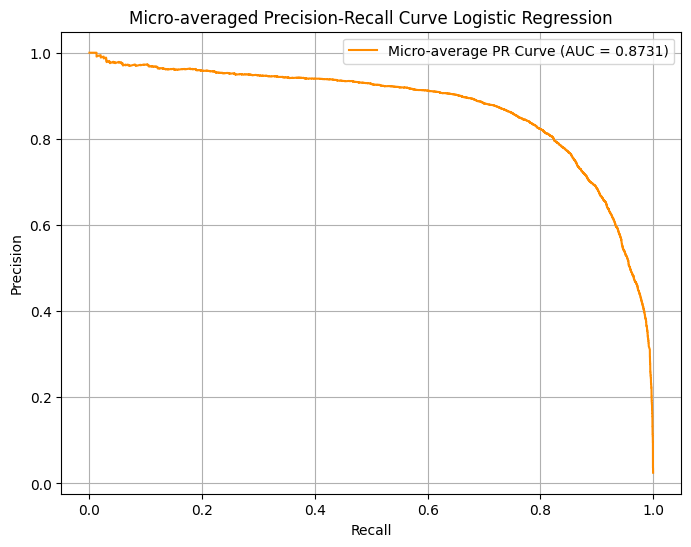

In [5]:
# ----------- Micro-Averaged PR-AUC ----------
precision_micro, recall_micro, _ = precision_recall_curve(
    y_val_bin.ravel(), y_scores.ravel()
)
pr_auc_micro = average_precision_score(y_val_bin, y_scores, average="micro")

print(f"🔍 Micro-averaged Precision-Recall AUC Logistic Regression: {pr_auc_micro:.4f}")

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_micro, precision_micro,
         label=f'Micro-average PR Curve (AUC = {pr_auc_micro:.4f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Micro-averaged Precision-Recall Curve Logistic Regression')
plt.legend()
plt.grid()
plt.show()

🔍 Macro-averaged Precision-Recall AUC Logistic Regression: 0.8090


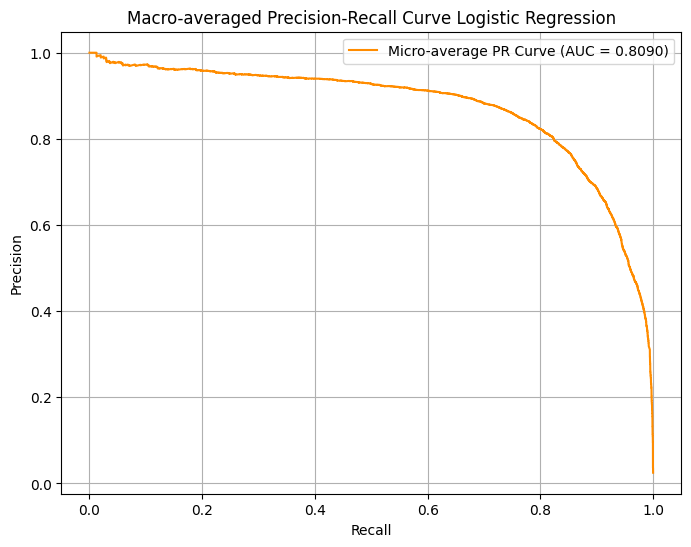

In [6]:
# ----------- Macro-Averaged PR-AUC ----------
precision_macro, recall_macro, _ = precision_recall_curve(
    y_val_bin.ravel(), y_scores.ravel()
)
pr_auc_macro = average_precision_score(y_val_bin, y_scores, average="macro")

print(f"🔍 Macro-averaged Precision-Recall AUC Logistic Regression: {pr_auc_macro:.4f}")

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_macro, precision_macro,
         label=f'Micro-average PR Curve (AUC = {pr_auc_macro:.4f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Macro-averaged Precision-Recall Curve Logistic Regression')
plt.legend()
plt.grid()
plt.show()

🔍 Weighted-averaged Precision-Recall AUC Logistic Regression: 0.8088


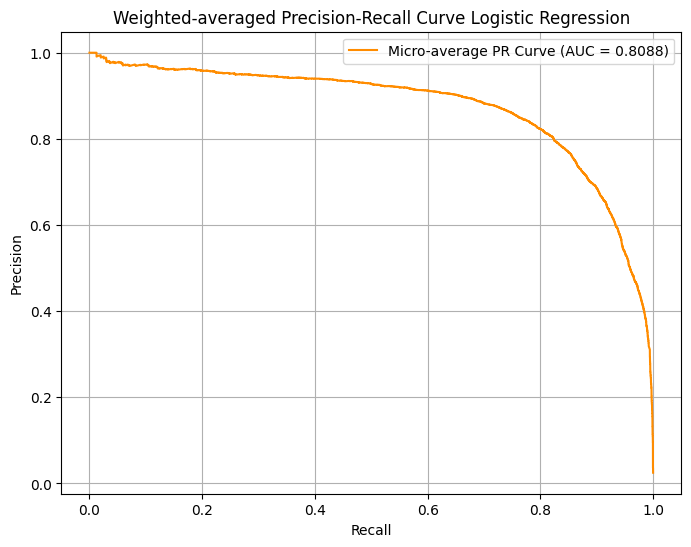

In [7]:
# ----------- Weighted-Averaged PR-AUC ----------
precision_wei, recall_wei, _ = precision_recall_curve(
    y_val_bin.ravel(), y_scores.ravel()
)
pr_auc_wei = average_precision_score(y_val_bin, y_scores, average="weighted")

print(f"🔍 Weighted-averaged Precision-Recall AUC Logistic Regression: {pr_auc_wei:.4f}")

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_wei, precision_wei,
         label=f'Micro-average PR Curve (AUC = {pr_auc_wei:.4f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Weighted-averaged Precision-Recall Curve Logistic Regression')
plt.legend()
plt.grid()
plt.show()

In [8]:
# -----------------------------
# Micro, Macro, Weighted Scores
# -----------------------------

# Get predicted probabilities
y_scores = best_classifier.predict_proba(x_val)

# Binarize true labels for multi-class PR-AUC
classes = np.unique(y_val)
y_val_bin = label_binarize(y_val, classes=classes)

# ----------- PR-AUC Scores -----------
pr_auc_micro = average_precision_score(y_val_bin, y_scores, average="micro")
pr_auc_macro = average_precision_score(y_val_bin, y_scores, average="macro")
pr_auc_wei = average_precision_score(y_val_bin, y_scores, average="weighted")

# ----------- Print PR-AUC Scores -----------
print(f"🔍 Micro-averaged Precision-Recall AUC Logistic Regression:   {pr_auc_micro:.4f}")
print(f"🔍 Macro-averaged Precision-Recall AUC Logistic Regression:   {pr_auc_macro:.4f}")
print(f"🔍 Weighted-averaged Precision-Recall Logistic Regression:   {pr_auc_wei:.4f}")

🔍 Micro-averaged Precision-Recall AUC Logistic Regression:   0.8731
🔍 Macro-averaged Precision-Recall AUC Logistic Regression:   0.8090
🔍 Weighted-averaged Precision-Recall Logistic Regression:   0.8088


Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best parameters from RandomizedSearchCV: {'random_state': 42, 'n_jobs': -1, 'n_estimators': 300, 'min_samples_split': 5, 'min_samples_leaf': 5, 'max_features': 'sqrt', 'max_depth': 30, 'class_weight': 'balanced', 'bootstrap': True}
Best cross-validation score: 0.8252493200362647
Cross-validation results:  {'fit_time': array([44.15225172, 44.06684852]), 'score_time': array([1.48100114, 1.44840193]), 'test_score': array([0.82082956, 0.82966908])}
Classification report for Random Forest: 
                                 precision    recall  f1-score   support

          Allergy / Immunology     0.9747    0.9914    0.9830       233
                       Autopsy     1.0000    1.0000    1.0000       224
                    Bariatrics     0.9280    0.9957    0.9607       233
    Cardiovascular / Pulmonary     0.5878    0.4265    0.4943       204
                  Chiropractic     0.8455    0.9292    0.8854       212
    Consult - 

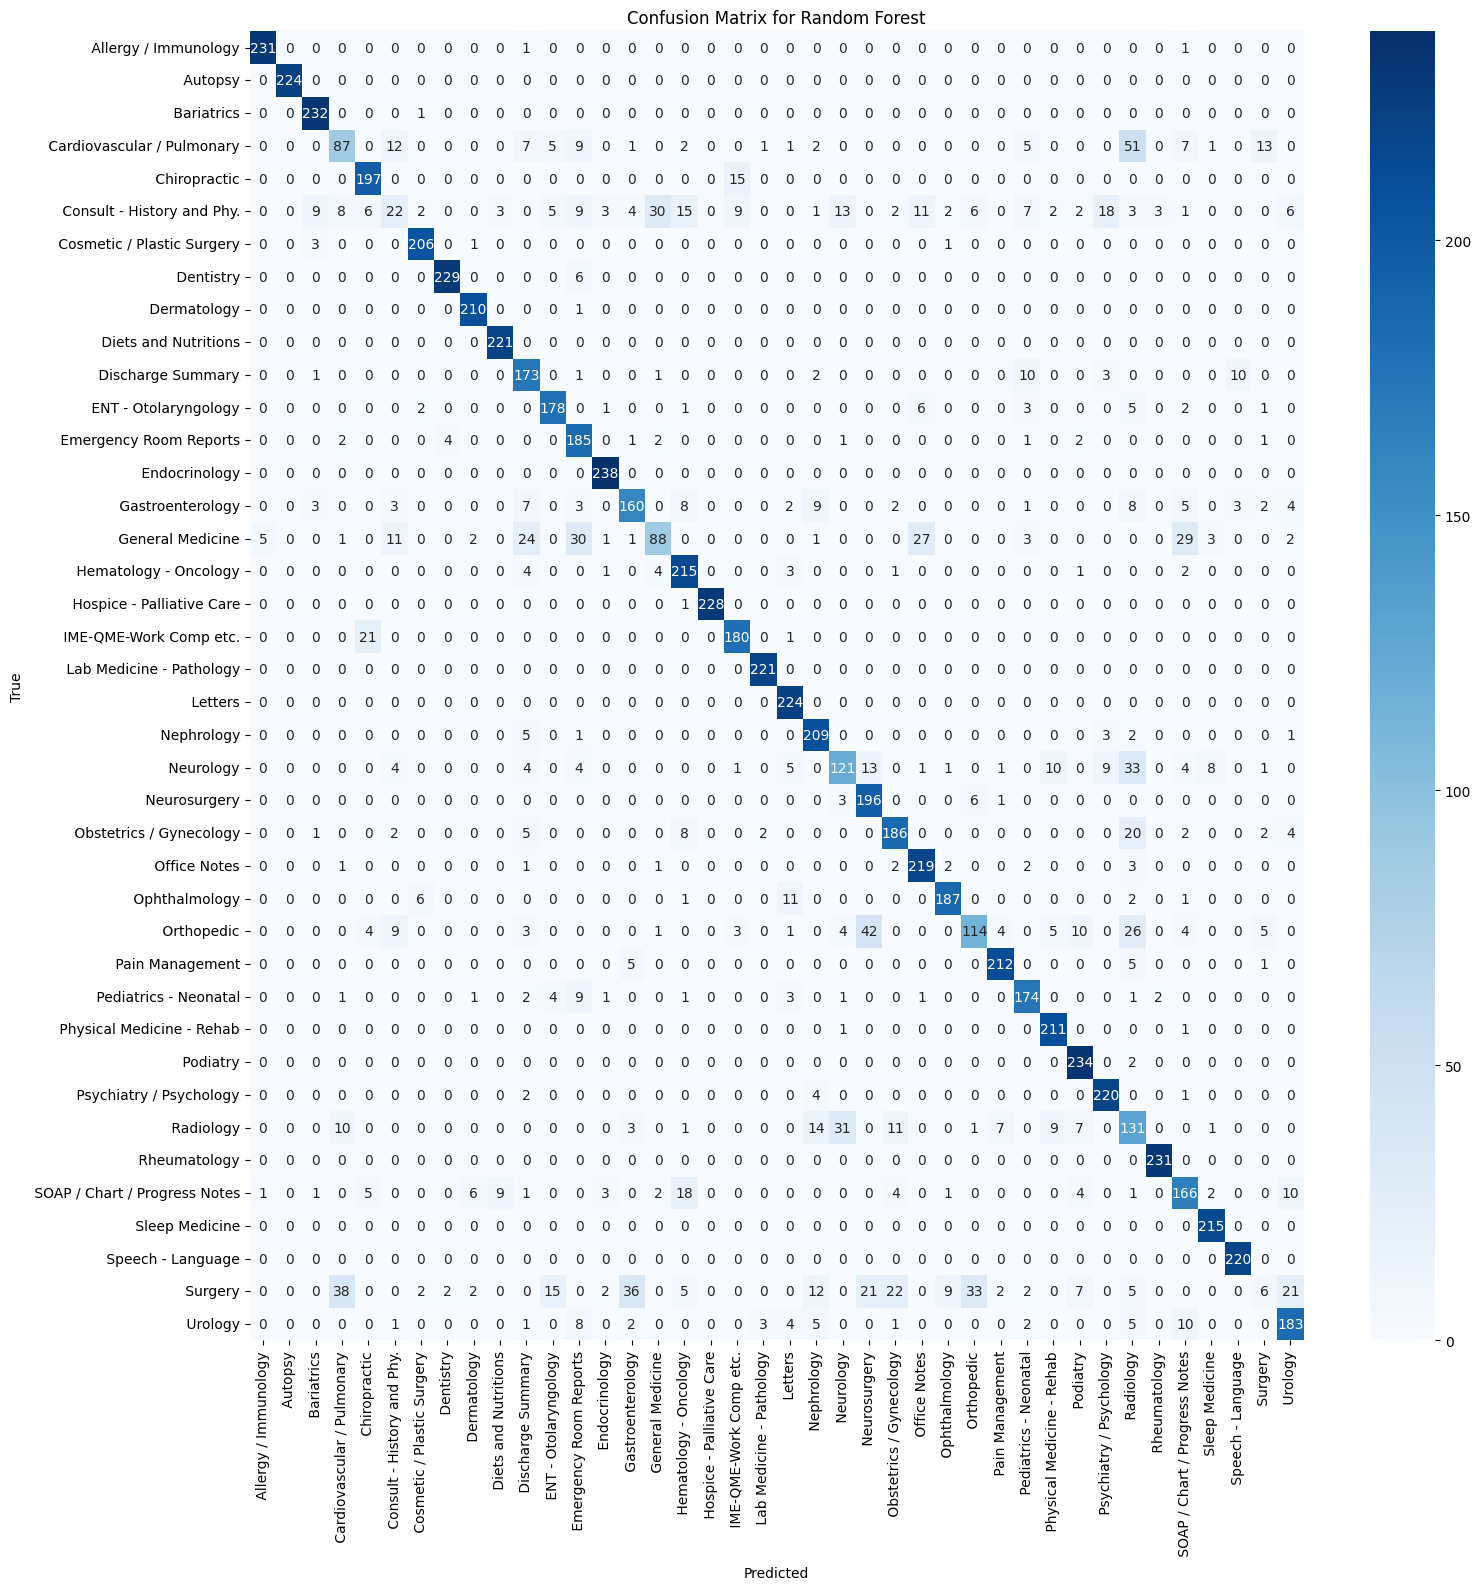

In [9]:
# ------------------------------------------
# Random Forest Classification Model
# ------------------------------------------

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.ensemble import RandomForestClassifier

# Define the RandomForestClassifier
classifier = RandomForestClassifier()

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'n_estimators': [100, 200, 300],  # Number of trees in the forest
    'max_depth': [10, 20, 30],         # Maximum depth of the tree
    'min_samples_split': [5, 10, 20],  # Minimum number of samples to split an internal node
    'min_samples_leaf': [5, 15, 25],   # Minimum number of samples at a leaf node
    'max_features': ['auto', 'sqrt'],  # Number of features to consider at each split
    'bootstrap': [True, False],        # Bootstrap sampling for tree construction
    'class_weight': ['balanced'],      # Class weighting for imbalanced datasets
    'n_jobs': [-1],                    # Use all available processors
    'random_state': [42]               # Random state for reproducibility
}

# RandomizedSearchCV for hyperparameter tuning with 2-fold cross-validation
random_search = RandomizedSearchCV(
    estimator=classifier, 
    param_distributions=param_dist,
    n_iter=10,  # Number of random parameter combinations to try
    cv=2,       # 2-fold cross-validation
    verbose=1,  # Verbosity to track progress
    random_state=42,
    n_jobs=-1   # Use all available processors
)

# Fit the model
random_search.fit(x_train, y_train)

# Best parameters
print(f"Best parameters from RandomizedSearchCV: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_}")

# Best estimator
best_classifier = random_search.best_estimator_

# Cross-validation results
cv_results = cross_validate(best_classifier, x_train, y_train, cv=2)
print("Cross-validation results: ", cv_results)

# Predictions
prediction = best_classifier.predict(x_val)

# Classification report
print('Classification report for Random Forest: \n',
      classification_report(y_val, prediction, target_names=list(le.classes_), digits=4))

# Confusion Matrix
conf_matrix = confusion_matrix(y_val, prediction)
plt.figure(figsize=(17, 17))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for Random Forest')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# For binary classification (choose class 1 as positive)
if len(np.unique(y_val)) == 2:
    TP = conf_matrix[1, 1]
    TN = conf_matrix[0, 0]
    FP = conf_matrix[0, 1]
    FN = conf_matrix[1, 0]

    print(f"True Positives (TP): {TP}")
    print(f"True Negatives (TN): {TN}")
    print(f"False Positives (FP): {FP}")
    print(f"False Negatives (FN): {FN}")

    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)

    print(f"True Positive Rate (TPR): {TPR}")
    print(f"False Positive Rate (FPR): {FPR}")

# --------------------------------------
# PR-AUC (Precision-Recall Curve and Area)
# --------------------------------------

# Get predicted probabilities
y_scores = best_classifier.predict_proba(x_val)

# Binarize labels
classes = np.unique(y_val)
y_val_bin = label_binarize(y_val, classes=classes)

# # Handle binary vs. multiclass
# if y_scores.shape[1] == 2:
#     # Binary classification
#     precision, recall, _ = precision_recall_curve(y_val, y_scores[:, 1])
#     pr_auc = average_precision_score(y_val, y_scores[:, 1])

#     print(f"Precision-Recall AUC (PR-AUC): {pr_auc:.4f}")

#     plt.figure(figsize=(10, 10))
#     plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.4f})', color='purple')
#     plt.xlabel('Recall')
#     plt.ylabel('Precision')
#     plt.title('Precision-Recall Curve (Binary)')
#     plt.legend()
#     plt.grid()
#     plt.show()

# else:
#     # Multiclass classification
#     plt.figure(figsize=(10, 8))
#     for i in range(len(classes)):
#         precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_scores[:, i])
#         pr_auc = average_precision_score(y_val_bin[:, i], y_scores[:, i])
#         plt.plot(recall, precision, label=f'{le.classes_[i]} (AUC = {pr_auc:.4f})')

#     plt.xlabel('Recall')
#     plt.ylabel('Precision')
#     plt.title('Precision-Recall Curve Per Class Random Forest ')
#     plt.legend(loc='lower left')
#     plt.grid()
#     plt.show()

🔍 Micro-averaged Precision-Recall AUC Random Forest: 0.9023


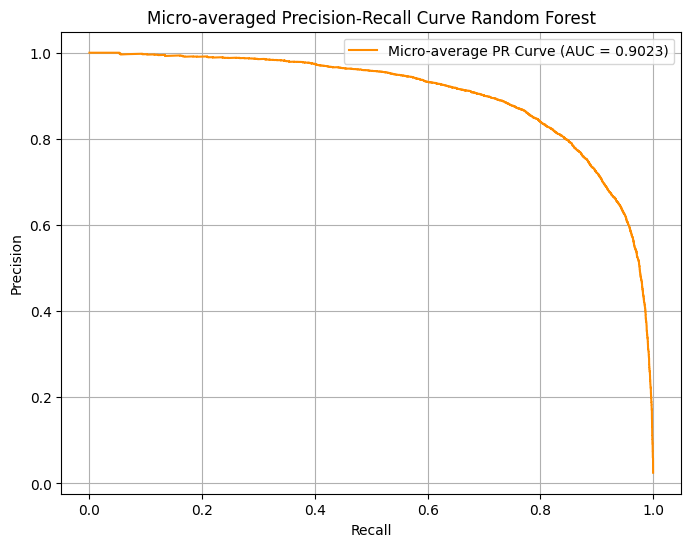

In [10]:
# ----------- Micro-Averaged PR-AUC ----------
precision_micro, recall_micro, _ = precision_recall_curve(
    y_val_bin.ravel(), y_scores.ravel()
)
pr_auc_micro = average_precision_score(y_val_bin, y_scores, average="micro")

print(f"🔍 Micro-averaged Precision-Recall AUC Random Forest: {pr_auc_micro:.4f}")

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_micro, precision_micro,
         label=f'Micro-average PR Curve (AUC = {pr_auc_micro:.4f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Micro-averaged Precision-Recall Curve Random Forest')
plt.legend()
plt.grid()
plt.show()

🔍 Macro-averaged Precision-Recall AUC Random Forest: 0.8351


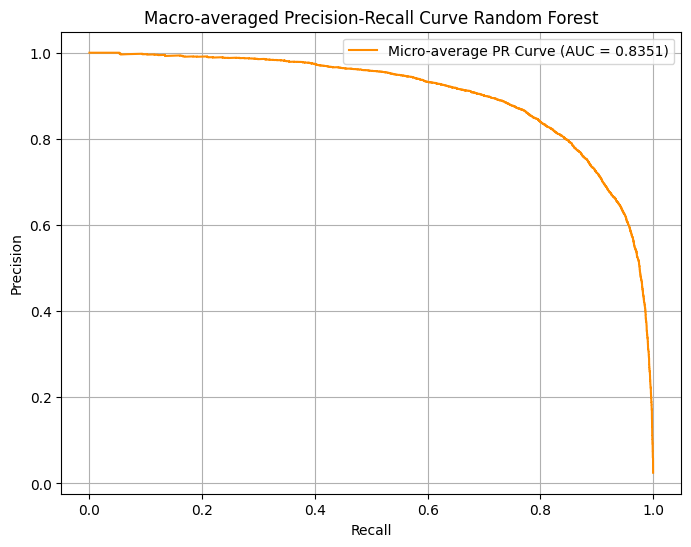

In [11]:
# ----------- Macro-Averaged PR-AUC ----------
precision_macro, recall_macro, _ = precision_recall_curve(
    y_val_bin.ravel(), y_scores.ravel()
)
pr_auc_macro = average_precision_score(y_val_bin, y_scores, average="macro")

print(f"🔍 Macro-averaged Precision-Recall AUC Random Forest: {pr_auc_macro:.4f}")

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_macro, precision_macro,
         label=f'Micro-average PR Curve (AUC = {pr_auc_macro:.4f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Macro-averaged Precision-Recall Curve Random Forest')
plt.legend()
plt.grid()
plt.show()

🔍 Weighted-averaged Precision-Recall AUC Random Forest: 0.8350


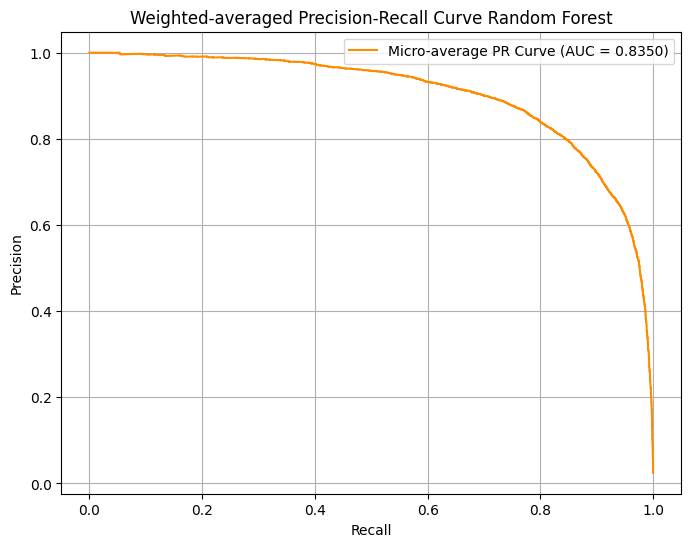

In [12]:
# ----------- Weighted-Averaged PR-AUC ----------
precision_wei, recall_wei, _ = precision_recall_curve(
    y_val_bin.ravel(), y_scores.ravel()
)
pr_auc_wei = average_precision_score(y_val_bin, y_scores, average="weighted")

print(f"🔍 Weighted-averaged Precision-Recall AUC Random Forest: {pr_auc_wei:.4f}")

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_wei, precision_wei,
         label=f'Micro-average PR Curve (AUC = {pr_auc_wei:.4f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Weighted-averaged Precision-Recall Curve Random Forest')
plt.legend()
plt.grid()
plt.show()

In [13]:
# -----------------------------
# Micro, Macro, Weighted Scores
# -----------------------------

# Get predicted probabilities
y_scores = best_classifier.predict_proba(x_val)

# Binarize true labels for multi-class PR-AUC
classes = np.unique(y_val)
y_val_bin = label_binarize(y_val, classes=classes)

# ----------- PR-AUC Scores -----------
pr_auc_micro = average_precision_score(y_val_bin, y_scores, average="micro")
pr_auc_macro = average_precision_score(y_val_bin, y_scores, average="macro")
pr_auc_wei = average_precision_score(y_val_bin, y_scores, average="weighted")

# ----------- Print PR-AUC Scores -----------
print(f"🔍 Micro-averaged Precision-Recall AUC Random Forest:   {pr_auc_micro:.4f}")
print(f"🔍 Macro-averaged Precision-Recall AUC Random Forest:   {pr_auc_macro:.4f}")
print(f"🔍 Weighted-averaged Precision-Recall Random Forest:   {pr_auc_wei:.4f}")

🔍 Micro-averaged Precision-Recall AUC Random Forest:   0.9023
🔍 Macro-averaged Precision-Recall AUC Random Forest:   0.8351
🔍 Weighted-averaged Precision-Recall Random Forest:   0.8350


Fitting 2 folds for each of 50 candidates, totalling 100 fits
Best parameters from RandomizedSearchCV: {'var_smoothing': 1.873817422860387e-09}
Best cross-validation score: 0.8561310063463282
Cross-validation results:  {'fit_time': array([1.77442741, 1.76049018]), 'score_time': array([25.44516516, 25.49508929]), 'test_score': array([0.85244787, 0.85981414])}
Classification report for Naive Bayes: 
                                 precision    recall  f1-score   support

          Allergy / Immunology     0.9790    1.0000    0.9894       233
                       Autopsy     1.0000    1.0000    1.0000       224
                    Bariatrics     0.9510    1.0000    0.9749       233
    Cardiovascular / Pulmonary     0.7099    0.4559    0.5552       204
                  Chiropractic     0.8618    1.0000    0.9258       212
    Consult - History and Phy.     0.6018    0.3366    0.4317       202
    Cosmetic / Plastic Surgery     0.9455    0.9858    0.9652       211
                     

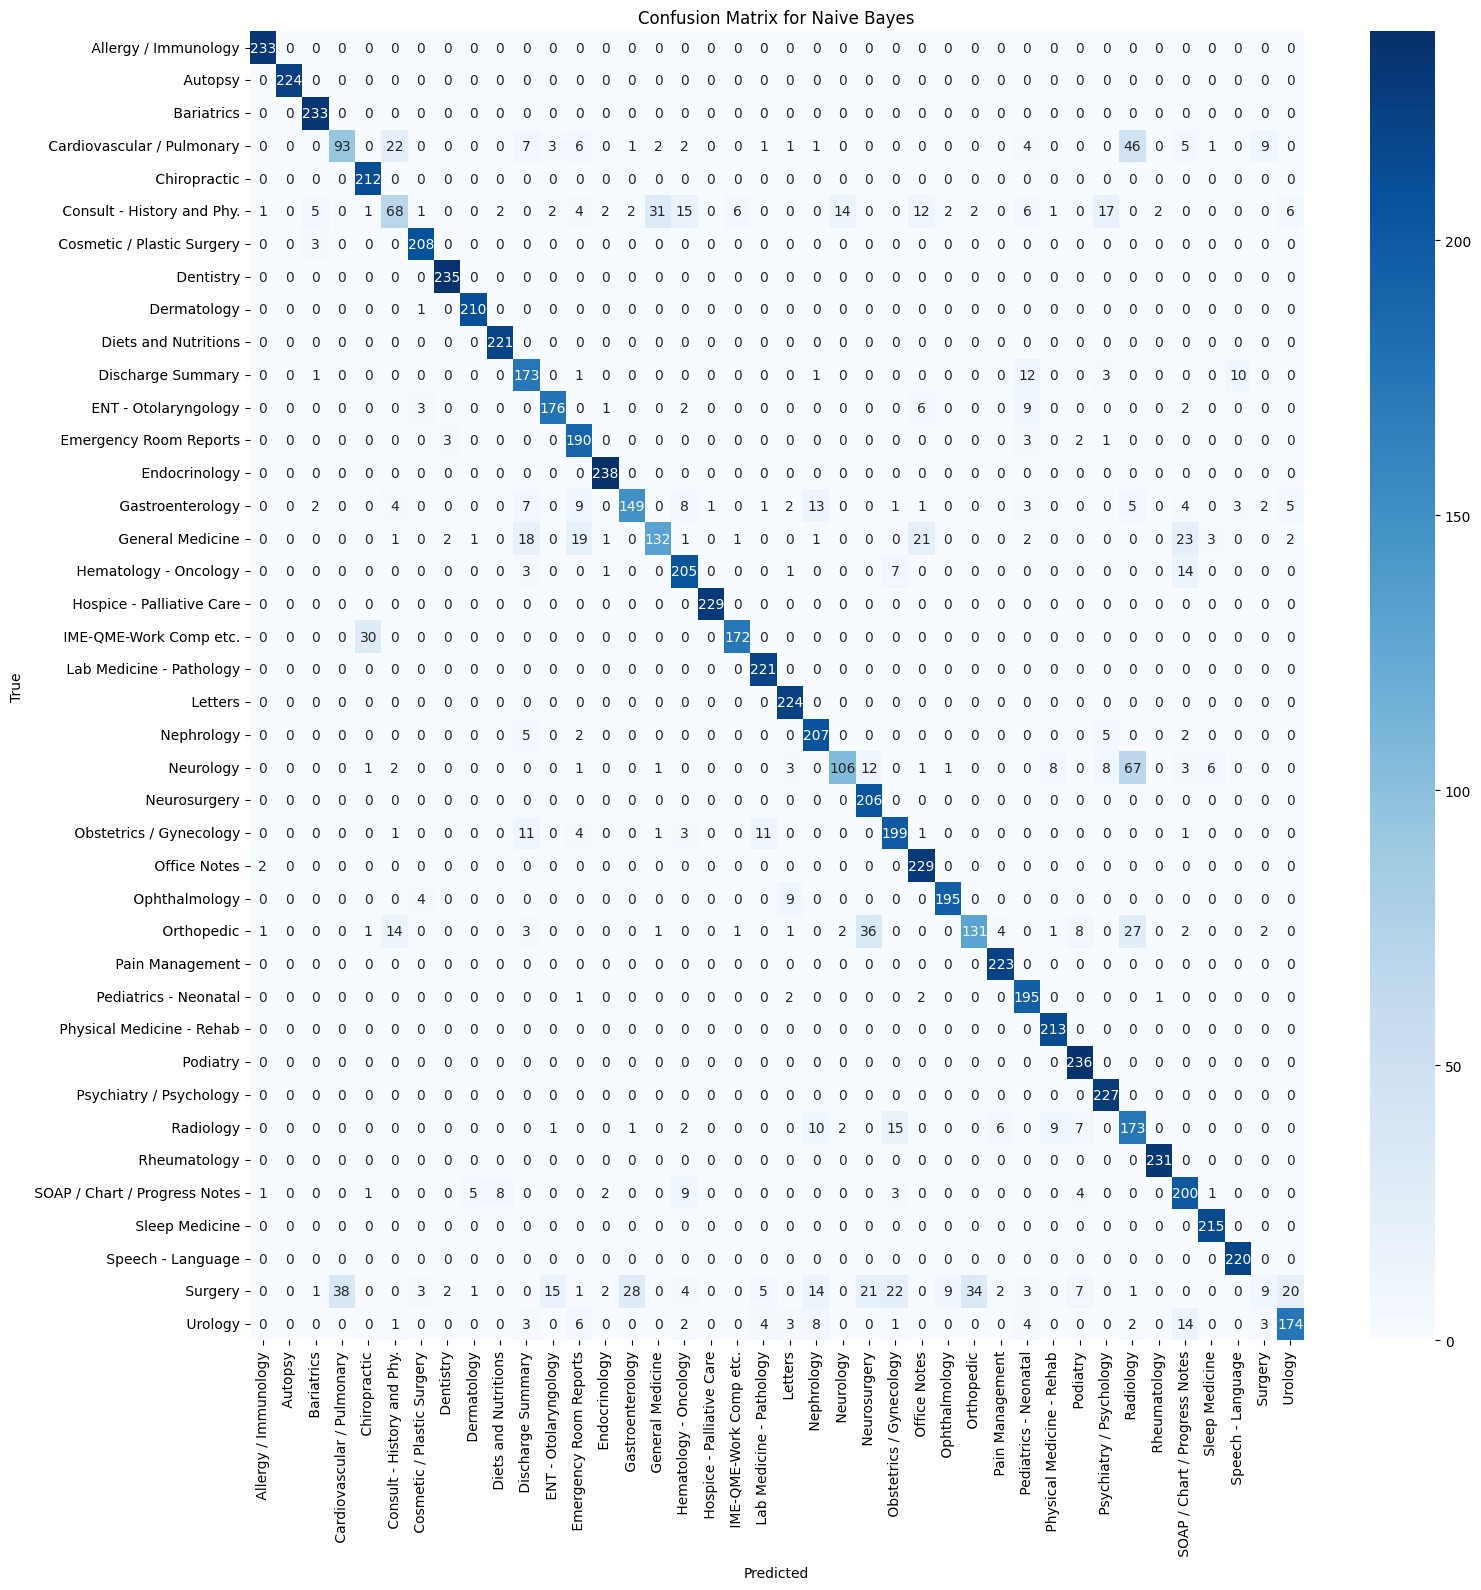

In [14]:
# ------------------------------------------
# Naive Bayes Classification Model
# ------------------------------------------

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.naive_bayes import GaussianNB

# Initialize the Gaussian Naive Bayes classifier
classifier = GaussianNB()

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'var_smoothing': np.logspace(0, -9, 100)  # range of possible smoothing values, from 1 to 1e-9
}

# Set up RandomizedSearchCV for hyperparameter tuning with cross-validation
random_search = RandomizedSearchCV(estimator=classifier, param_distributions=param_dist, 
                                   n_iter=50, cv=2, n_jobs=-1, verbose=1, random_state=42)


# Fit the model
random_search.fit(x_train, y_train)

# Best parameters
print(f"Best parameters from RandomizedSearchCV: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_}")

# Best estimator
best_classifier = random_search.best_estimator_

# Cross-validation results
cv_results = cross_validate(best_classifier, x_train, y_train, cv=2)
print("Cross-validation results: ", cv_results)

# Predictions
prediction = best_classifier.predict(x_val)

# Classification report
print('Classification report for Naive Bayes: \n',
      classification_report(y_val, prediction, target_names=list(le.classes_), digits=4))

# Confusion Matrix
conf_matrix = confusion_matrix(y_val, prediction)
plt.figure(figsize=(17, 17))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for Naive Bayes')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# For binary classification (choose class 1 as positive)
# if len(np.unique(y_val)) == 2:
#     TP = conf_matrix[1, 1]
#     TN = conf_matrix[0, 0]
#     FP = conf_matrix[0, 1]
#     FN = conf_matrix[1, 0]

#     print(f"True Positives (TP): {TP}")
#     print(f"True Negatives (TN): {TN}")
#     print(f"False Positives (FP): {FP}")
#     print(f"False Negatives (FN): {FN}")

#     TPR = TP / (TP + FN)
#     FPR = FP / (FP + TN)

#     print(f"True Positive Rate (TPR): {TPR}")
#     print(f"False Positive Rate (FPR): {FPR}")

# --------------------------------------
# PR-AUC (Precision-Recall Curve and Area)
# --------------------------------------

# Get predicted probabilities
y_scores = best_classifier.predict_proba(x_val)

# Binarize labels
classes = np.unique(y_val)
y_val_bin = label_binarize(y_val, classes=classes)

# Handle binary vs. multiclass
# if y_scores.shape[1] == 2:
#     # Binary classification
#     precision, recall, _ = precision_recall_curve(y_val, y_scores[:, 1])
#     pr_auc = average_precision_score(y_val, y_scores[:, 1])

#     print(f"Precision-Recall AUC (PR-AUC): {pr_auc:.4f}")

#     plt.figure(figsize=(10, 10))
#     plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.4f})', color='purple')
#     plt.xlabel('Recall')
#     plt.ylabel('Precision')
#     plt.title('Precision-Recall Curve (Binary)')
#     plt.legend()
#     plt.grid()
#     plt.show()

# else:
#     # Multiclass classification
#     plt.figure(figsize=(10, 8))
#     for i in range(len(classes)):
#         precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_scores[:, i])
#         pr_auc = average_precision_score(y_val_bin[:, i], y_scores[:, i])
#         plt.plot(recall, precision, label=f'{le.classes_[i]} (AUC = {pr_auc:.4f})')

#     plt.xlabel('Recall')
#     plt.ylabel('Precision')
#     plt.title('Precision-Recall Curve Per Class Logistic Regression ')
#     plt.legend(loc='lower left')
#     plt.grid()
#     plt.show()

🔍 Micro-averaged Precision-Recall AUC Naive Bayes: 0.7584


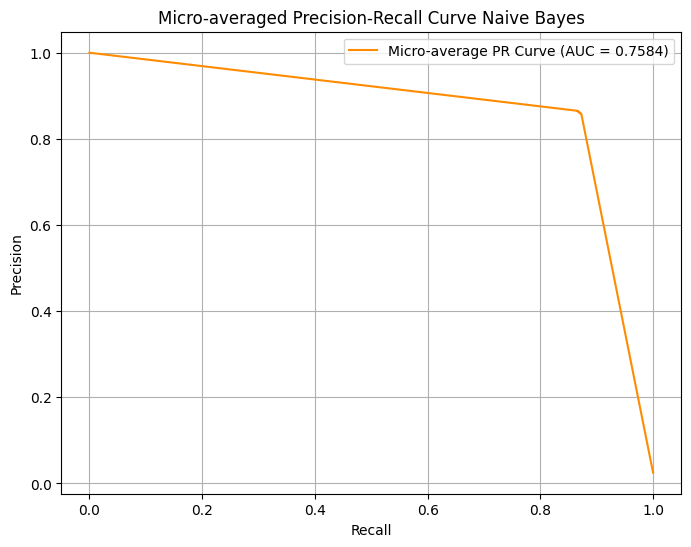

In [15]:
# ----------- Micro-Averaged PR-AUC ----------
precision_micro, recall_micro, _ = precision_recall_curve(
    y_val_bin.ravel(), y_scores.ravel()
)
pr_auc_micro = average_precision_score(y_val_bin, y_scores, average="micro")

print(f"🔍 Micro-averaged Precision-Recall AUC Naive Bayes: {pr_auc_micro:.4f}")

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_micro, precision_micro,
         label=f'Micro-average PR Curve (AUC = {pr_auc_micro:.4f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Micro-averaged Precision-Recall Curve Naive Bayes')
plt.legend()
plt.grid()
plt.show()

🔍 Macro-averaged Precision-Recall AUC Naive Bayes: 0.7700


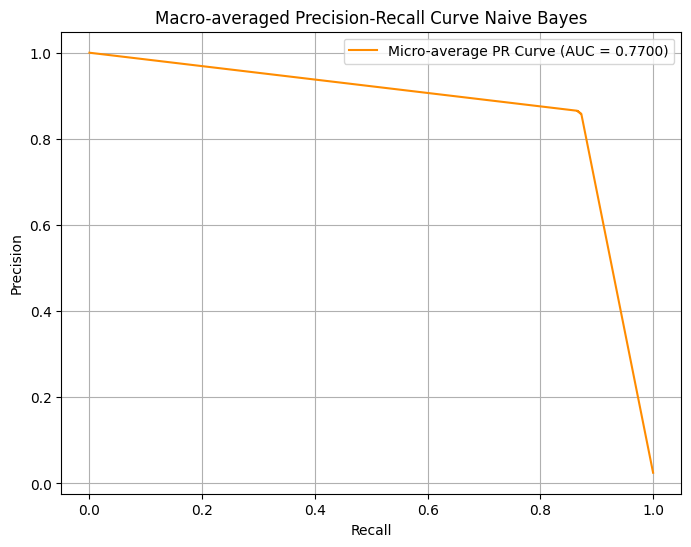

In [16]:
# ----------- Macro-Averaged PR-AUC ----------
precision_macro, recall_macro, _ = precision_recall_curve(
    y_val_bin.ravel(), y_scores.ravel()
)
pr_auc_macro = average_precision_score(y_val_bin, y_scores, average="macro")

print(f"🔍 Macro-averaged Precision-Recall AUC Naive Bayes: {pr_auc_macro:.4f}")

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_macro, precision_macro,
         label=f'Micro-average PR Curve (AUC = {pr_auc_macro:.4f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Macro-averaged Precision-Recall Curve Naive Bayes')
plt.legend()
plt.grid()
plt.show()

🔍 Weighted-averaged Precision-Recall AUC Naive Bayes: 0.7702


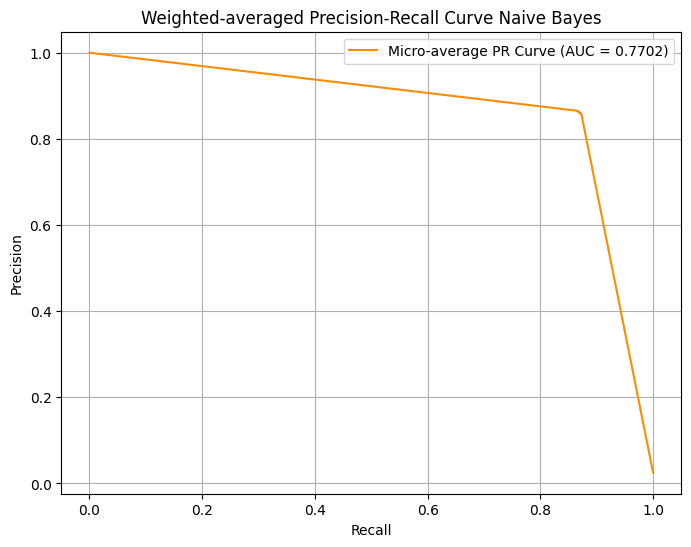

In [17]:
# ----------- Weighted-Averaged PR-AUC ----------
precision_wei, recall_wei, _ = precision_recall_curve(
    y_val_bin.ravel(), y_scores.ravel()
)
pr_auc_wei = average_precision_score(y_val_bin, y_scores, average="weighted")

print(f"🔍 Weighted-averaged Precision-Recall AUC Naive Bayes: {pr_auc_wei:.4f}")

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_wei, precision_wei,
         label=f'Micro-average PR Curve (AUC = {pr_auc_wei:.4f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Weighted-averaged Precision-Recall Curve Naive Bayes')
plt.legend()
plt.grid()
plt.show()

In [18]:
# -----------------------------
# Micro, Macro, Weighted Scores
# -----------------------------

# Get predicted probabilities
y_scores = best_classifier.predict_proba(x_val)

# Binarize true labels for multi-class PR-AUC
classes = np.unique(y_val)
y_val_bin = label_binarize(y_val, classes=classes)

# ----------- PR-AUC Scores -----------
pr_auc_micro = average_precision_score(y_val_bin, y_scores, average="micro")
pr_auc_macro = average_precision_score(y_val_bin, y_scores, average="macro")
pr_auc_wei = average_precision_score(y_val_bin, y_scores, average="weighted")

# ----------- Print PR-AUC Scores -----------
print(f"🔍 Micro-averaged Precision-Recall AUC Naive Bayes:   {pr_auc_micro:.4f}")
print(f"🔍 Macro-averaged Precision-Recall AUC Naive Bayes:   {pr_auc_macro:.4f}")
print(f"🔍 Weighted-averaged Precision-Recall Naive Bayes:   {pr_auc_wei:.4f}")

🔍 Micro-averaged Precision-Recall AUC Naive Bayes:   0.7584
🔍 Macro-averaged Precision-Recall AUC Naive Bayes:   0.7700
🔍 Weighted-averaged Precision-Recall Naive Bayes:   0.7702


Fitting 2 folds for each of 50 candidates, totalling 100 fits
Best parameters from RandomizedSearchCV: {'splitter': 'best', 'random_state': 42, 'min_samples_split': 5, 'min_samples_leaf': 2, 'max_features': None, 'max_depth': None, 'criterion': 'entropy', 'class_weight': None}
Best cross-validation score: 0.7481017679057117
Cross-validation results:  {'fit_time': array([49.7504096 , 50.21424484]), 'score_time': array([0.23798275, 0.24109411]), 'test_score': array([0.74546691, 0.75073663])}
Classification report for Decision Tree: 
                                 precision    recall  f1-score   support

          Allergy / Immunology     0.9914    0.9871    0.9892       233
                       Autopsy     1.0000    0.9955    0.9978       224
                    Bariatrics     0.9309    0.9828    0.9562       233
    Cardiovascular / Pulmonary     0.3971    0.5294    0.4538       204
                  Chiropractic     0.8800    0.9340    0.9062       212
    Consult - History and Phy

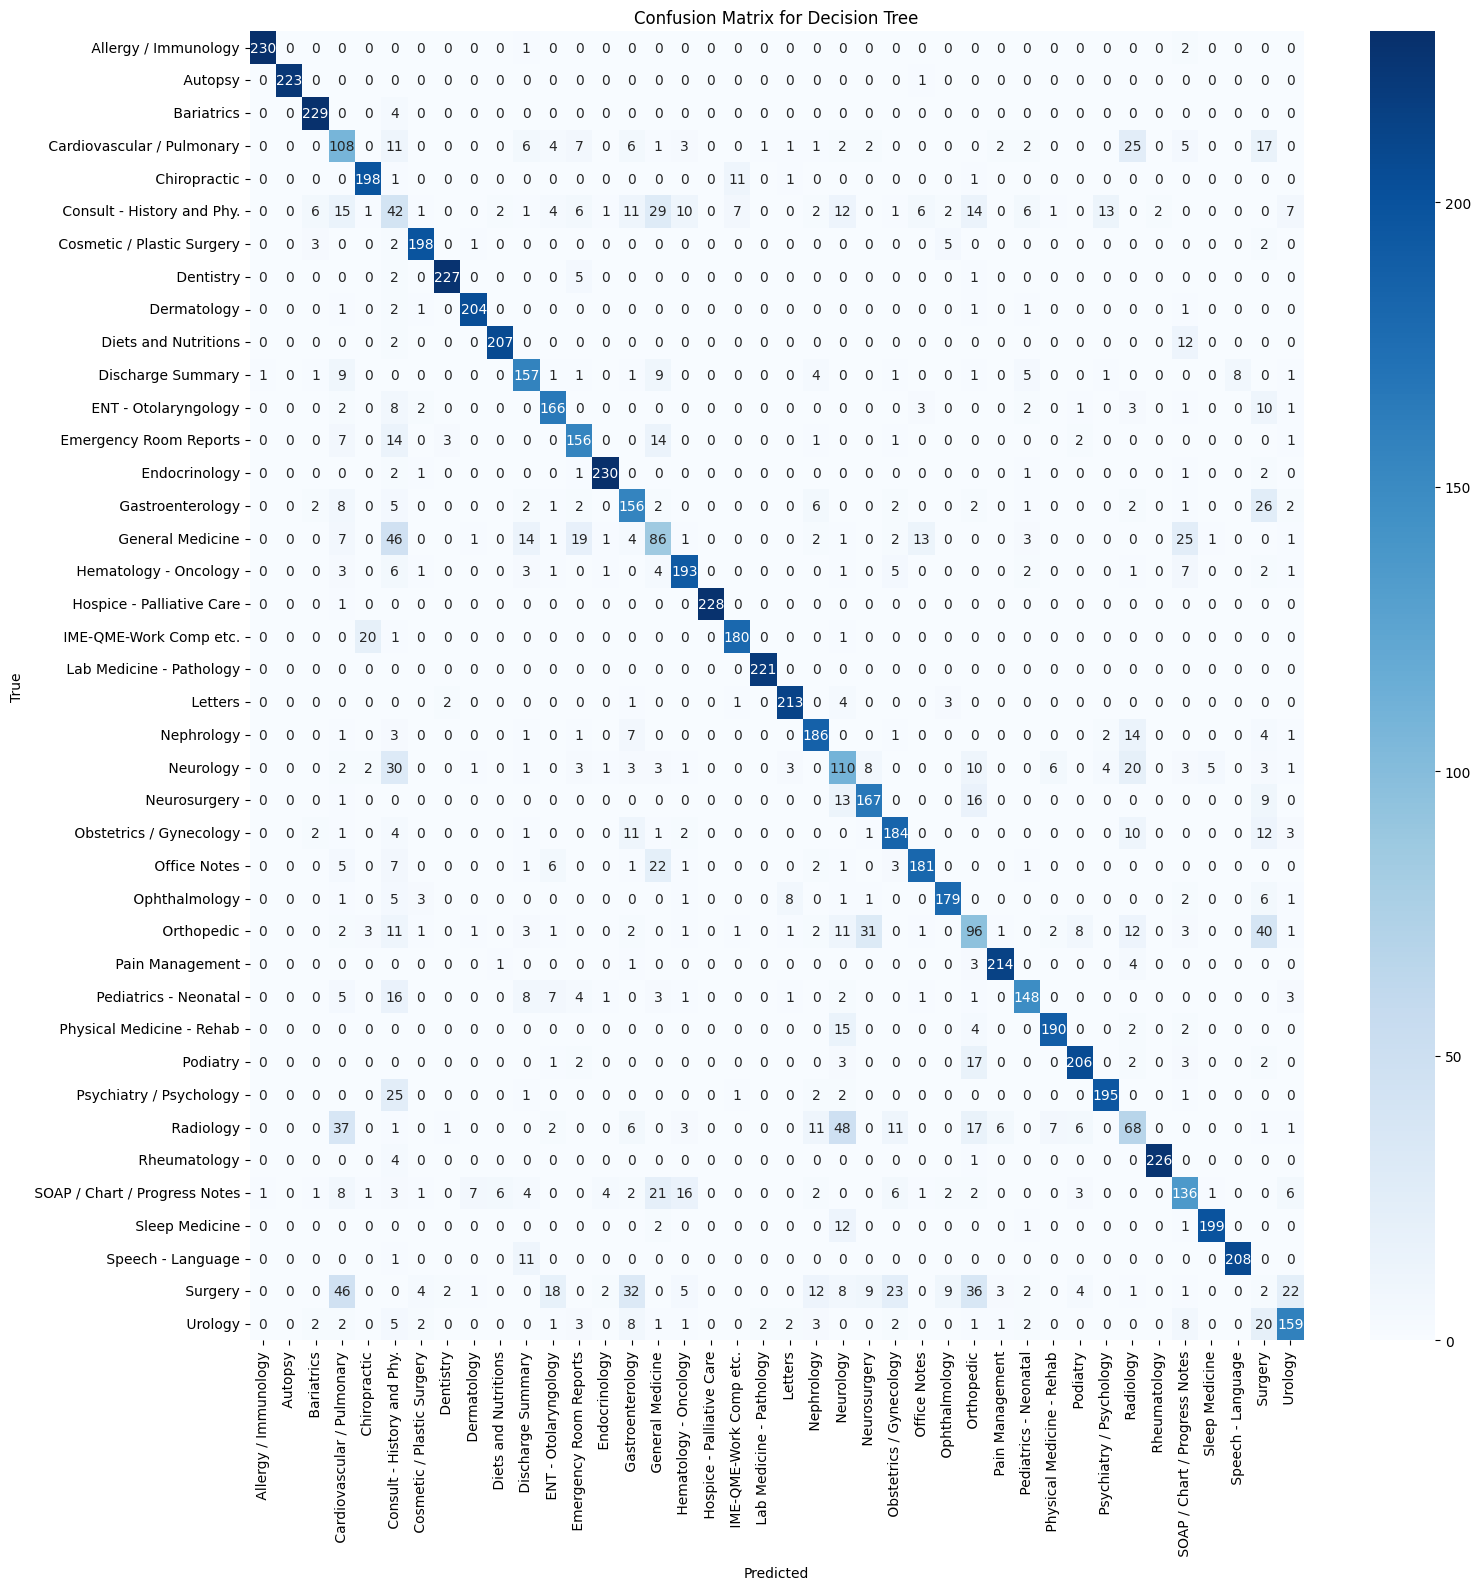

In [36]:
# ------------------------------------------
# Decision Tree Classification Model
# ------------------------------------------

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.tree import DecisionTreeClassifier

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'criterion': ['gini', 'entropy'],  # Split quality criterion
    'max_depth': [None, 10, 20, 30, 40],  # Max depth of tree (None means expand until leaves are pure)
    'min_samples_split': [2, 5, 10, 20],  # Min samples required to split a node
    'min_samples_leaf': [1, 2, 4, 10],    # Min samples required at a leaf node
    'max_features': ['auto', 'sqrt', 'log2', None],  # Number of features to consider for splits
    'splitter': ['best', 'random'],      # Strategy used to split at each node
    'class_weight': [None, 'balanced'],  # Use 'balanced' for class weighting in imbalanced datasets
    'random_state': [42],  # Ensures reproducibility
}

# Initialize the DecisionTreeClassifier
classifier = DecisionTreeClassifier()

# Set up RandomizedSearchCV for hyperparameter tuning with cross-validation
random_search = RandomizedSearchCV(estimator=classifier, param_distributions=param_dist, 
                                   n_iter=50, cv=2, n_jobs=-1, verbose=1, random_state=42)


# Fit the model
random_search.fit(x_train, y_train)

# Best parameters
print(f"Best parameters from RandomizedSearchCV: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_}")

# Best estimator
best_classifier = random_search.best_estimator_

# Cross-validation results
cv_results = cross_validate(best_classifier, x_train, y_train, cv=2)
print("Cross-validation results: ", cv_results)

# Predictions
prediction = best_classifier.predict(x_val)

# Classification report
print('Classification report for Decision Tree: \n',
      classification_report(y_val, prediction, target_names=list(le.classes_), digits=4))

# Confusion Matrix
conf_matrix = confusion_matrix(y_val, prediction)
plt.figure(figsize=(17, 17))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for Decision Tree')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# For binary classification (choose class 1 as positive)
if len(np.unique(y_val)) == 2:
    TP = conf_matrix[1, 1]
    TN = conf_matrix[0, 0]
    FP = conf_matrix[0, 1]
    FN = conf_matrix[1, 0]

    print(f"True Positives (TP): {TP}")
    print(f"True Negatives (TN): {TN}")
    print(f"False Positives (FP): {FP}")
    print(f"False Negatives (FN): {FN}")

    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)

    print(f"True Positive Rate (TPR): {TPR}")
    print(f"False Positive Rate (FPR): {FPR}")

# --------------------------------------
# PR-AUC (Precision-Recall Curve and Area)
# --------------------------------------

# Get predicted probabilities
y_scores = best_classifier.predict_proba(x_val)

# Binarize labels
classes = np.unique(y_val)
y_val_bin = label_binarize(y_val, classes=classes)

# # Handle binary vs. multiclass
# if y_scores.shape[1] == 2:
#     # Binary classification
#     precision, recall, _ = precision_recall_curve(y_val, y_scores[:, 1])
#     pr_auc = average_precision_score(y_val, y_scores[:, 1])

#     print(f"Precision-Recall AUC (PR-AUC): {pr_auc:.4f}")

#     plt.figure(figsize=(10, 10))
#     plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.4f})', color='purple')
#     plt.xlabel('Recall')
#     plt.ylabel('Precision')
#     plt.title('Precision-Recall Curve (Binary)')
#     plt.legend()
#     plt.grid()
#     plt.show()

# else:
#     # Multiclass classification
#     plt.figure(figsize=(10, 8))
#     for i in range(len(classes)):
#         precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_scores[:, i])
#         pr_auc = average_precision_score(y_val_bin[:, i], y_scores[:, i])
#         plt.plot(recall, precision, label=f'{le.classes_[i]} (AUC = {pr_auc:.4f})')

#     plt.xlabel('Recall')
#     plt.ylabel('Precision')
#     plt.title('Precision-Recall Curve Per Class Random Forest ')
#     plt.legend(loc='lower left')
#     plt.grid()
#     plt.show()

🔍 Micro-averaged Precision-Recall AUC Decision Tree: 0.7004


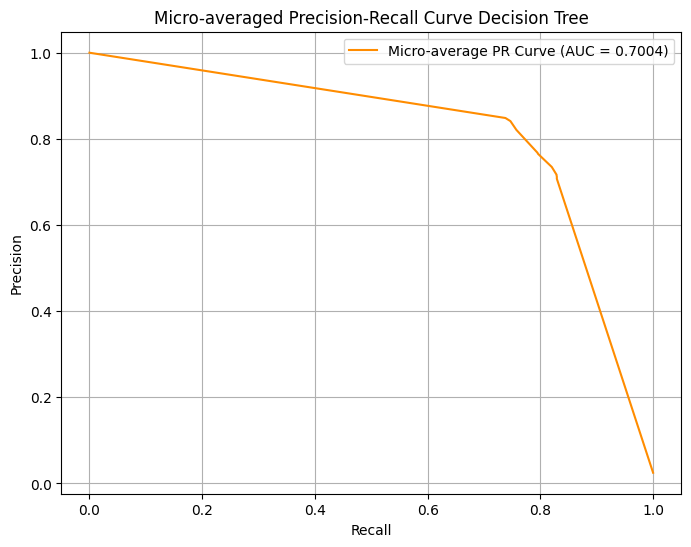

In [37]:
# ----------- Micro-Averaged PR-AUC ----------
precision_micro, recall_micro, _ = precision_recall_curve(
    y_val_bin.ravel(), y_scores.ravel()
)
pr_auc_micro = average_precision_score(y_val_bin, y_scores, average="micro")

print(f"🔍 Micro-averaged Precision-Recall AUC Decision Tree: {pr_auc_micro:.4f}")

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_micro, precision_micro,
         label=f'Micro-average PR Curve (AUC = {pr_auc_micro:.4f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Micro-averaged Precision-Recall Curve Decision Tree')
plt.legend()
plt.grid()
plt.show()

🔍 Macro-averaged Precision-Recall AUC Decision Tree: 0.7197


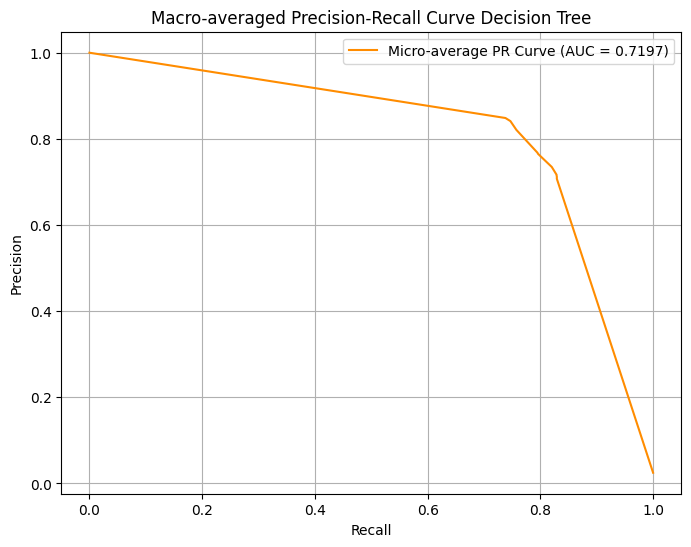

In [38]:
# ----------- Macro-Averaged PR-AUC ----------
precision_macro, recall_macro, _ = precision_recall_curve(
    y_val_bin.ravel(), y_scores.ravel()
)
pr_auc_macro = average_precision_score(y_val_bin, y_scores, average="macro")

print(f"🔍 Macro-averaged Precision-Recall AUC Decision Tree: {pr_auc_macro:.4f}")

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_macro, precision_macro,
         label=f'Micro-average PR Curve (AUC = {pr_auc_macro:.4f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Macro-averaged Precision-Recall Curve Decision Tree')
plt.legend()
plt.grid()
plt.show()

🔍 Weighted-averaged Precision-Recall AUC Decision Tree: 0.7202


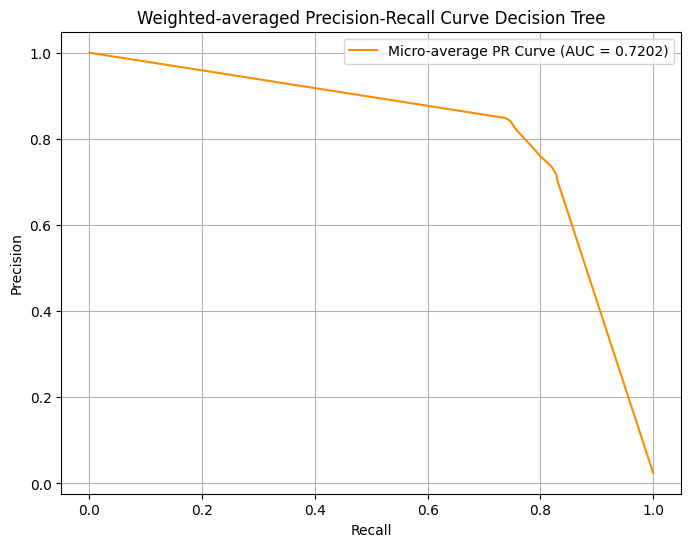

In [39]:
# ----------- Weighted-Averaged PR-AUC ----------
precision_wei, recall_wei, _ = precision_recall_curve(
    y_val_bin.ravel(), y_scores.ravel()
)
pr_auc_wei = average_precision_score(y_val_bin, y_scores, average="weighted")

print(f"🔍 Weighted-averaged Precision-Recall AUC Decision Tree: {pr_auc_wei:.4f}")

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_wei, precision_wei,
         label=f'Micro-average PR Curve (AUC = {pr_auc_wei:.4f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Weighted-averaged Precision-Recall Curve Decision Tree')
plt.legend()
plt.grid()
plt.show()

In [40]:
# -----------------------------
# Micro, Macro, Weighted Scores
# -----------------------------

# Get predicted probabilities
y_scores = best_classifier.predict_proba(x_val)

# Binarize true labels for multi-class PR-AUC
classes = np.unique(y_val)
y_val_bin = label_binarize(y_val, classes=classes)

# ----------- PR-AUC Scores -----------
pr_auc_micro = average_precision_score(y_val_bin, y_scores, average="micro")
pr_auc_macro = average_precision_score(y_val_bin, y_scores, average="macro")
pr_auc_wei = average_precision_score(y_val_bin, y_scores, average="weighted")

# ----------- Print PR-AUC Scores -----------
print(f"🔍 Micro-averaged Precision-Recall AUC Decision Tree:   {pr_auc_micro:.4f}")
print(f"🔍 Macro-averaged Precision-Recall AUC Decision Tree:   {pr_auc_macro:.4f}")
print(f"🔍 Weighted-averaged Precision-Recall Decision Tree:   {pr_auc_wei:.4f}")

🔍 Micro-averaged Precision-Recall AUC Decision Tree:   0.7004
🔍 Macro-averaged Precision-Recall AUC Decision Tree:   0.7197
🔍 Weighted-averaged Precision-Recall Decision Tree:   0.7202


Fitting 2 folds for each of 10 candidates, totalling 20 fits
Best parameters from RandomizedSearchCV: {'validation_fraction': 0.2, 'solver': 'adam', 'n_iter_no_change': 10, 'max_iter': 100, 'learning_rate_init': 0.001, 'learning_rate': 'constant', 'hidden_layer_sizes': (100,), 'early_stopping': False, 'batch_size': 'auto', 'alpha': 0.001, 'activation': 'relu'}
Best cross-validation score: 0.8345704895738895
Cross-validation results:  {'fit_time': array([159.39723253, 159.25755548]), 'score_time': array([0.45967293, 0.45090389]), 'test_score': array([0.83459882, 0.843835  ])}
Classification report for MLP: 
                                 precision    recall  f1-score   support

          Allergy / Immunology     0.9749    1.0000    0.9873       233
                       Autopsy     1.0000    1.0000    1.0000       224
                    Bariatrics     0.9588    1.0000    0.9790       233
    Cardiovascular / Pulmonary     0.5625    0.4853    0.5211       204
                  Chirop

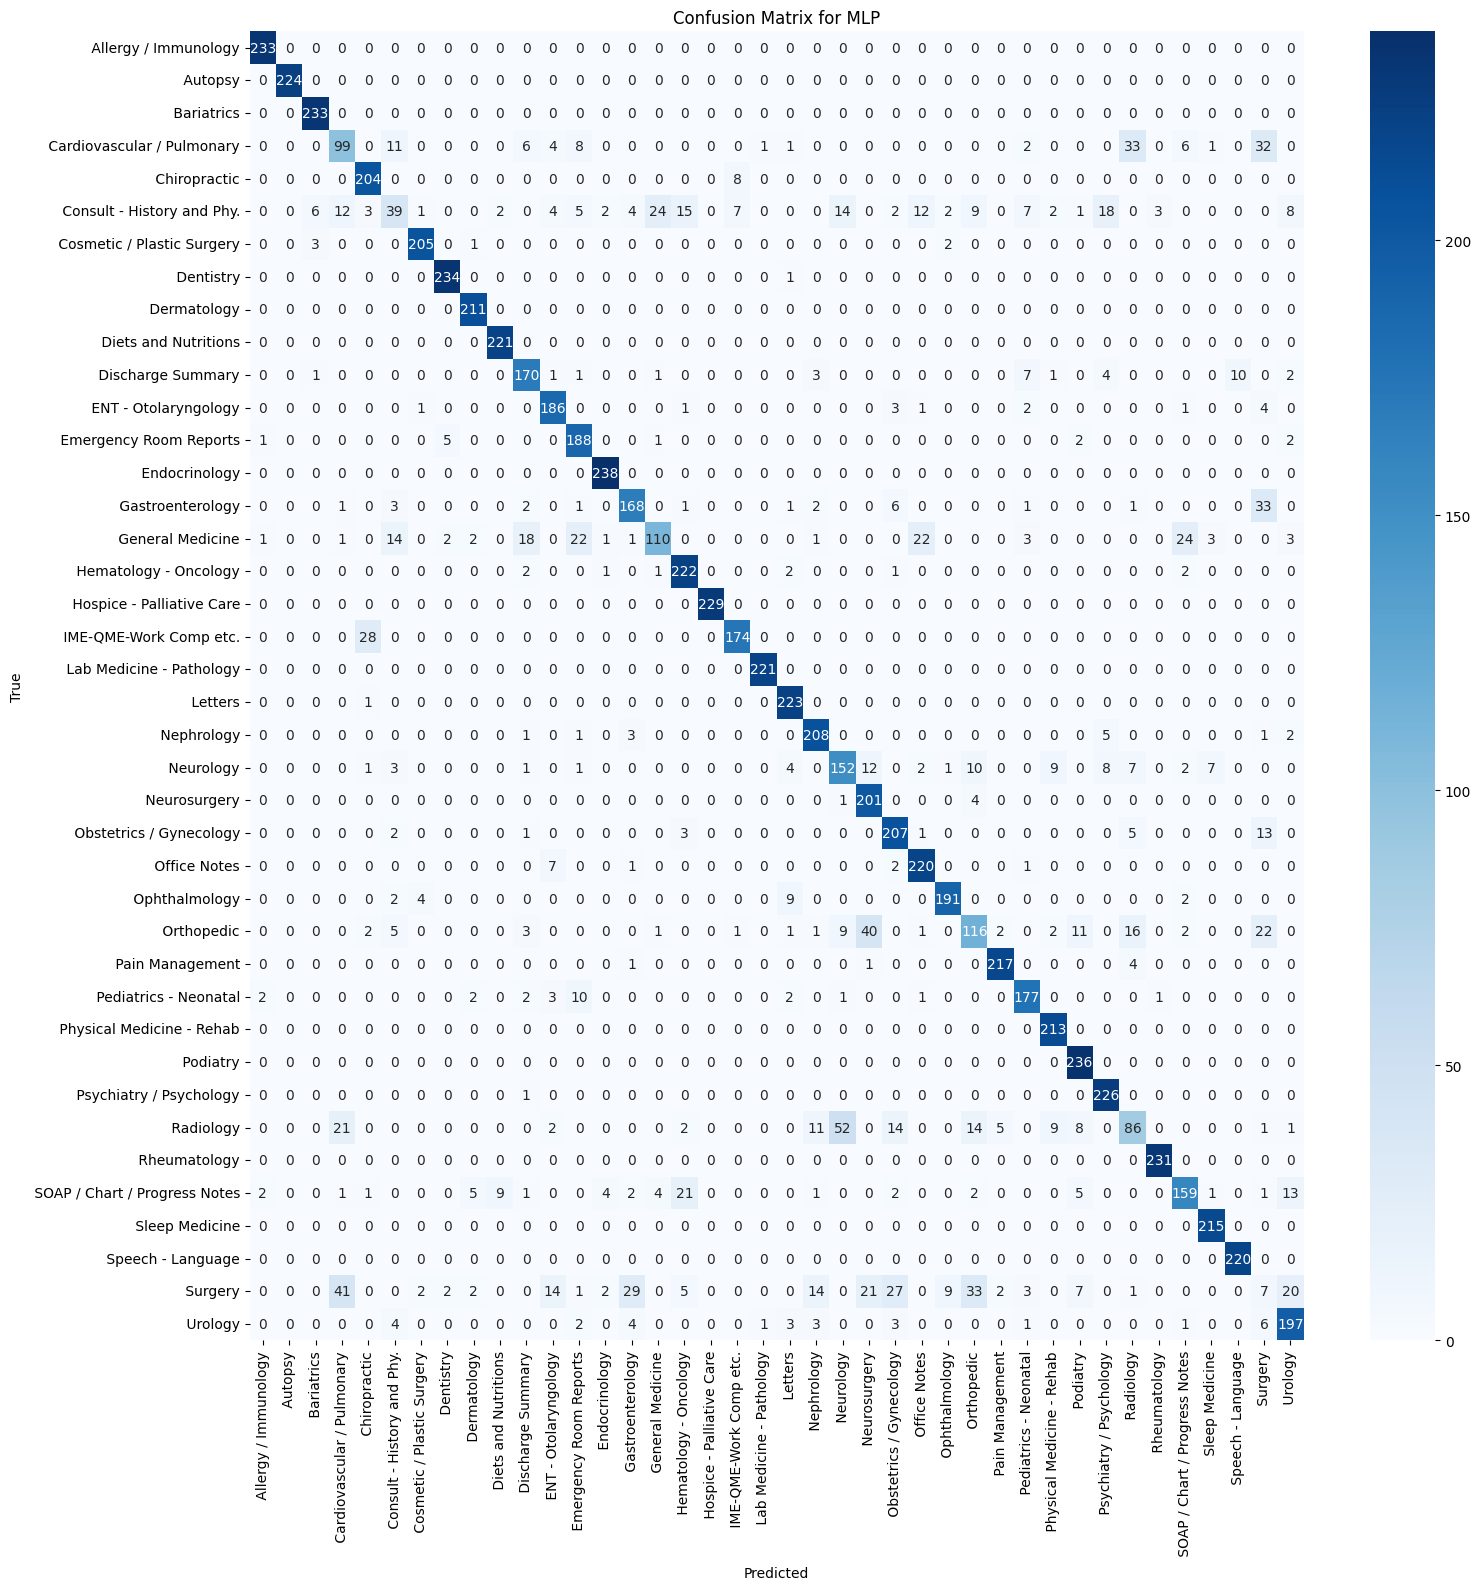

In [25]:
# ------------------------------------------
# MLP Classification Model
# ------------------------------------------

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.neural_network import MLPClassifier 

# Initialize the MLPClassifier (without specifying hyperparameters, so RandomizedSearchCV will handle that)
classifier = MLPClassifier()

# Define the parameter distribution for RandomizedSearchCV
param_dist = {
    'hidden_layer_sizes': [(50,), (100,), (50, 50), (100, 100)],  # Different architectures (single and multi-layer)
    'activation': ['relu', 'tanh', 'logistic'],  # Activation function
    'solver': ['adam', 'sgd'],  # Optimization solver
    'alpha': [0.0001, 0.001, 0.01],  # L2 penalty (regularization)
    'learning_rate': ['constant', 'invscaling', 'adaptive'],  # Learning rate schedule
    'learning_rate_init': [0.001, 0.01, 0.1],  # Initial learning rate
    'batch_size': ['auto', 32, 64],  # Batch size for the SGD solver
    'max_iter': [100, 250, 500],  # Maximum number of iterations for training
    'early_stopping': [True, False],  # Whether to use early stopping to avoid overfitting
    'validation_fraction': [0.1, 0.2],  # Proportion of training data to set aside for early stopping
    'n_iter_no_change': [10, 20],  # Number of iterations with no improvement after which training will stop
}

# RandomizedSearchCV for hyperparameter tuning
random_search = RandomizedSearchCV(
    estimator=classifier,
    param_distributions=param_dist,
    n_iter=10,  # Number of random combinations to try
    cv=2,  # 2-fold cross-validation
    verbose=1,  # Verbosity to track progress
    random_state=42,
    n_jobs=-1  # Use all available cores
)


# Fit the model
random_search.fit(x_train, y_train)

# Best parameters
print(f"Best parameters from RandomizedSearchCV: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_}")

# Best estimator
best_classifier = random_search.best_estimator_

# Cross-validation results
cv_results = cross_validate(best_classifier, x_train, y_train, cv=2)
print("Cross-validation results: ", cv_results)

# Predictions
prediction = best_classifier.predict(x_val)

# Classification report
print('Classification report for MLP: \n',
      classification_report(y_val, prediction, target_names=list(le.classes_), digits=4))

# Confusion Matrix
conf_matrix = confusion_matrix(y_val, prediction)
plt.figure(figsize=(17, 17))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for MLP')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# For binary classification (choose class 1 as positive)
if len(np.unique(y_val)) == 2:
    TP = conf_matrix[1, 1]
    TN = conf_matrix[0, 0]
    FP = conf_matrix[0, 1]
    FN = conf_matrix[1, 0]

    print(f"True Positives (TP): {TP}")
    print(f"True Negatives (TN): {TN}")
    print(f"False Positives (FP): {FP}")
    print(f"False Negatives (FN): {FN}")

    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)

    print(f"True Positive Rate (TPR): {TPR}")
    print(f"False Positive Rate (FPR): {FPR}")

# --------------------------------------
# PR-AUC (Precision-Recall Curve and Area)
# --------------------------------------

# Get predicted probabilities
y_scores = best_classifier.predict_proba(x_val)

# Binarize labels
classes = np.unique(y_val)
y_val_bin = label_binarize(y_val, classes=classes)

# # Handle binary vs. multiclass
# if y_scores.shape[1] == 2:
#     # Binary classification
#     precision, recall, _ = precision_recall_curve(y_val, y_scores[:, 1])
#     pr_auc = average_precision_score(y_val, y_scores[:, 1])

#     print(f"Precision-Recall AUC (PR-AUC): {pr_auc:.4f}")

#     plt.figure(figsize=(10, 10))
#     plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.4f})', color='purple')
#     plt.xlabel('Recall')
#     plt.ylabel('Precision')
#     plt.title('Precision-Recall Curve (Binary)')
#     plt.legend()
#     plt.grid()
#     plt.show()

# else:
#     # Multiclass classification
#     plt.figure(figsize=(10, 8))
#     for i in range(len(classes)):
#         precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_scores[:, i])
#         pr_auc = average_precision_score(y_val_bin[:, i], y_scores[:, i])
#         plt.plot(recall, precision, label=f'{le.classes_[i]} (AUC = {pr_auc:.4f})')

#     plt.xlabel('Recall')
#     plt.ylabel('Precision')
#     plt.title('Precision-Recall Curve Per Class Random Forest ')
#     plt.legend(loc='lower left')
#     plt.grid()
#     plt.show()

🔍 Micro-averaged Precision-Recall AUC MLP: 0.8971


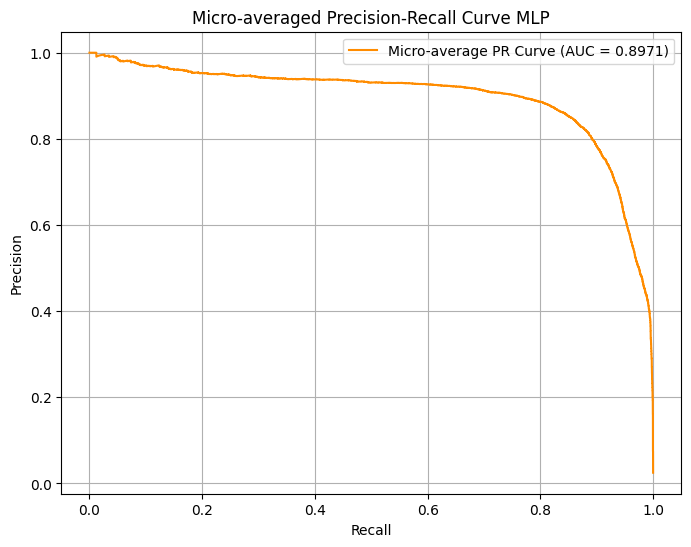

In [32]:
# ----------- Micro-Averaged PR-AUC ----------
precision_micro, recall_micro, _ = precision_recall_curve(
    y_val_bin.ravel(), y_scores.ravel()
)
pr_auc_micro = average_precision_score(y_val_bin, y_scores, average="micro")

print(f"🔍 Micro-averaged Precision-Recall AUC MLP: {pr_auc_micro:.4f}")

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_micro, precision_micro,
         label=f'Micro-average PR Curve (AUC = {pr_auc_micro:.4f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Micro-averaged Precision-Recall Curve MLP')
plt.legend()
plt.grid()
plt.show()

🔍 Macro-averaged Precision-Recall AUC MLP: 0.8439


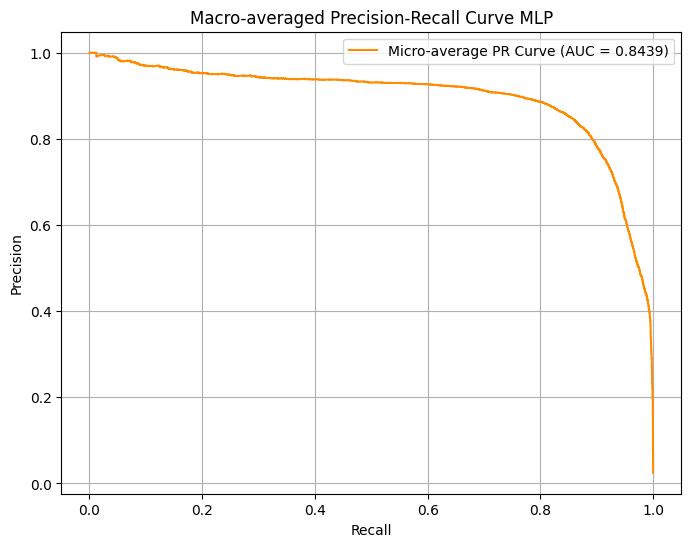

In [33]:
# ----------- Macro-Averaged PR-AUC ----------
precision_macro, recall_macro, _ = precision_recall_curve(
    y_val_bin.ravel(), y_scores.ravel()
)
pr_auc_macro = average_precision_score(y_val_bin, y_scores, average="macro")

print(f"🔍 Macro-averaged Precision-Recall AUC MLP: {pr_auc_macro:.4f}")

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_macro, precision_macro,
         label=f'Micro-average PR Curve (AUC = {pr_auc_macro:.4f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Macro-averaged Precision-Recall Curve MLP')
plt.legend()
plt.grid()
plt.show()

🔍 Weighted-averaged Precision-Recall AUC MLP: 0.8434


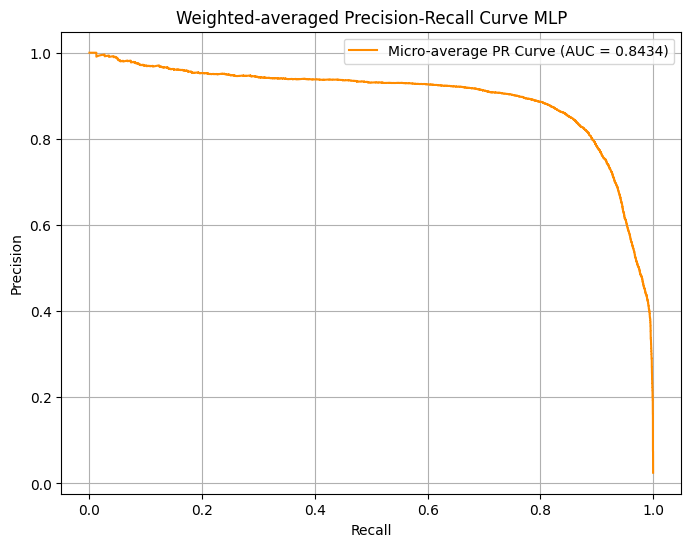

In [34]:
# ----------- Weighted-Averaged PR-AUC ----------
precision_wei, recall_wei, _ = precision_recall_curve(
    y_val_bin.ravel(), y_scores.ravel()
)
pr_auc_wei = average_precision_score(y_val_bin, y_scores, average="weighted")

print(f"🔍 Weighted-averaged Precision-Recall AUC MLP: {pr_auc_wei:.4f}")

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_wei, precision_wei,
         label=f'Micro-average PR Curve (AUC = {pr_auc_wei:.4f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Weighted-averaged Precision-Recall Curve MLP')
plt.legend()
plt.grid()
plt.show()

In [35]:
# -----------------------------
# Micro, Macro, Weighted Scores
# -----------------------------

# Get predicted probabilities
y_scores = best_classifier.predict_proba(x_val)

# Binarize true labels for multi-class PR-AUC
classes = np.unique(y_val)
y_val_bin = label_binarize(y_val, classes=classes)

# ----------- PR-AUC Scores -----------
pr_auc_micro = average_precision_score(y_val_bin, y_scores, average="micro")
pr_auc_macro = average_precision_score(y_val_bin, y_scores, average="macro")
pr_auc_wei = average_precision_score(y_val_bin, y_scores, average="weighted")

# ----------- Print PR-AUC Scores -----------
print(f"🔍 Micro-averaged Precision-Recall AUC MLP:   {pr_auc_micro:.4f}")
print(f"🔍 Macro-averaged Precision-Recall AUC MLP:   {pr_auc_macro:.4f}")
print(f"🔍 Weighted-averaged Precision-Recall MLP:   {pr_auc_wei:.4f}")

🔍 Micro-averaged Precision-Recall AUC MLP:   0.8971
🔍 Macro-averaged Precision-Recall AUC MLP:   0.8439
🔍 Weighted-averaged Precision-Recall MLP:   0.8434


In [ ]:
# ------------------------------------------
# SVM Classification Model
# ------------------------------------------

from sklearn.metrics import (
    classification_report, confusion_matrix, roc_curve, auc,
    precision_recall_curve, average_precision_score
)
from sklearn.preprocessing import label_binarize
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np
from sklearn.model_selection import RandomizedSearchCV, cross_validate
from sklearn.svm import SVC

# Define the Support Vector Machine model
classifier = SVC()  # Set probability=True to use predict_proba for ROC curve

# Define the parameter distribution for hyperparameter tuning
param_dist = {
    'C': [0.01, 0.1, 1],                # Regularization parameter
    'kernel': ['linear', 'rbf'],         # Type of kernel to use for SVM
    'gamma': ['scale', 'auto'],         # Kernel coefficient
    'tol': [1e-1, 1e-2],                # Tolerance for stopping criteria
    'class_weight': ['None', 'balanced'], # Adjust class weights
}

# Set up RandomizedSearchCV for hyperparameter tuning with 2-fold cross-validation
random_search = RandomizedSearchCV(estimator=classifier, param_distributions=param_dist, 
                                   n_iter=10, cv=2, n_jobs=-1, verbose=1, scoring='accuracy', random_state=42)

# Fit the model
random_search.fit(x_train, y_train)

# Best parameters
print(f"Best parameters from RandomizedSearchCV: {random_search.best_params_}")
print(f"Best cross-validation score: {random_search.best_score_}")

# Best estimator
best_classifier = random_search.best_estimator_

# Cross-validation results
cv_results = cross_validate(best_classifier, x_train, y_train, cv=2)
print("Cross-validation results: ", cv_results)

# Predictions
prediction = best_classifier.predict(x_val)

# Classification report
print('Classification report for SVM: \n',
      classification_report(y_val, prediction, target_names=list(le.classes_), digits=4))

# Confusion Matrix
conf_matrix = confusion_matrix(y_val, prediction)
plt.figure(figsize=(17, 17))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues',
            xticklabels=le.classes_, yticklabels=le.classes_)
plt.title('Confusion Matrix for SVM')
plt.xlabel('Predicted')
plt.ylabel('True')
plt.show()

# For binary classification (choose class 1 as positive)
if len(np.unique(y_val)) == 2:
    TP = conf_matrix[1, 1]
    TN = conf_matrix[0, 0]
    FP = conf_matrix[0, 1]
    FN = conf_matrix[1, 0]

    print(f"True Positives (TP): {TP}")
    print(f"True Negatives (TN): {TN}")
    print(f"False Positives (FP): {FP}")
    print(f"False Negatives (FN): {FN}")

    TPR = TP / (TP + FN)
    FPR = FP / (FP + TN)

    print(f"True Positive Rate (TPR): {TPR}")
    print(f"False Positive Rate (FPR): {FPR}")

# --------------------------------------
# PR-AUC (Precision-Recall Curve and Area)
# --------------------------------------

# Get predicted probabilities
y_scores = best_classifier.predict_proba(x_val)

# Binarize labels
classes = np.unique(y_val)
y_val_bin = label_binarize(y_val, classes=classes)

# # Handle binary vs. multiclass
# if y_scores.shape[1] == 2:
#     # Binary classification
#     precision, recall, _ = precision_recall_curve(y_val, y_scores[:, 1])
#     pr_auc = average_precision_score(y_val, y_scores[:, 1])

#     print(f"Precision-Recall AUC (PR-AUC): {pr_auc:.4f}")

#     plt.figure(figsize=(10, 10))
#     plt.plot(recall, precision, label=f'PR Curve (AUC = {pr_auc:.4f})', color='purple')
#     plt.xlabel('Recall')
#     plt.ylabel('Precision')
#     plt.title('Precision-Recall Curve (Binary)')
#     plt.legend()
#     plt.grid()
#     plt.show()

# else:
#     # Multiclass classification
#     plt.figure(figsize=(10, 8))
#     for i in range(len(classes)):
#         precision, recall, _ = precision_recall_curve(y_val_bin[:, i], y_scores[:, i])
#         pr_auc = average_precision_score(y_val_bin[:, i], y_scores[:, i])
#         plt.plot(recall, precision, label=f'{le.classes_[i]} (AUC = {pr_auc:.4f})')

#     plt.xlabel('Recall')
#     plt.ylabel('Precision')
#     plt.title('Precision-Recall Curve Per Class Random Forest ')
#     plt.legend(loc='lower left')
#     plt.grid()
#     plt.show()

In [ ]:
# ----------- Micro-Averaged PR-AUC ----------
precision_micro, recall_micro, _ = precision_recall_curve(
    y_val_bin.ravel(), y_scores.ravel()
)
pr_auc_micro = average_precision_score(y_val_bin, y_scores, average="micro")

print(f"🔍 Micro-averaged Precision-Recall AUC SVM: {pr_auc_micro:.4f}")

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_micro, precision_micro,
         label=f'Micro-average PR Curve (AUC = {pr_auc_micro:.4f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Micro-averaged Precision-Recall Curve SVM')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# ----------- Macro-Averaged PR-AUC ----------
precision_macro, recall_macro, _ = precision_recall_curve(
    y_val_bin.ravel(), y_scores.ravel()
)
pr_auc_macro = average_precision_score(y_val_bin, y_scores, average="macro")

print(f"🔍 Macro-averaged Precision-Recall AUC SVM: {pr_auc_macro:.4f}")

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_macro, precision_macro,
         label=f'Micro-average PR Curve (AUC = {pr_auc_macro:.4f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Macro-averaged Precision-Recall Curve SVM')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# ----------- Weighted-Averaged PR-AUC ----------
precision_wei, recall_wei, _ = precision_recall_curve(
    y_val_bin.ravel(), y_scores.ravel()
)
pr_auc_wei = average_precision_score(y_val_bin, y_scores, average="weighted")

print(f"🔍 Weighted-averaged Precision-Recall AUC SVM: {pr_auc_wei:.4f}")

# Plot micro-average PR curve
plt.figure(figsize=(8, 6))
plt.plot(recall_wei, precision_wei,
         label=f'Micro-average PR Curve (AUC = {pr_auc_wei:.4f})', color='darkorange')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Weighted-averaged Precision-Recall Curve SVM')
plt.legend()
plt.grid()
plt.show()

In [ ]:
# -----------------------------
# Micro, Macro, Weighted Scores
# -----------------------------

# Get predicted probabilities
y_scores = best_classifier.predict_proba(x_val)

# Binarize true labels for multi-class PR-AUC
classes = np.unique(y_val)
y_val_bin = label_binarize(y_val, classes=classes)

# ----------- PR-AUC Scores -----------
pr_auc_micro = average_precision_score(y_val_bin, y_scores, average="micro")
pr_auc_macro = average_precision_score(y_val_bin, y_scores, average="macro")
pr_auc_wei = average_precision_score(y_val_bin, y_scores, average="weighted")

# ----------- Print PR-AUC Scores -----------
print(f"🔍 Micro-averaged Precision-Recall AUC SVM:   {pr_auc_micro:.4f}")
print(f"🔍 Macro-averaged Precision-Recall AUC SVM:   {pr_auc_macro:.4f}")
print(f"🔍 Weighted-averaged Precision-Recall SVM:   {pr_auc_wei:.4f}")